# Project 2 - Autoregressive forecast with autocorrelated loads for a 10 port network

<b>Import Python Libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
from statsmodels.graphics.tsaplots import plot_acf
from itertools import combinations

<b>Parameters

In [36]:
networkFactor = 100    # To change the characteristics of the network (Y)
cosPhi=0.95            # Value of teta
time=24                # Training Period  
timeForecast=12        # Test Period

error_load=0.25
error_pv=0.5

# ── Fixed defaults ────────────────────────────────────────────────────────────
DEFAULT_LAG_PV      = 0.95
DEFAULT_LAG_LOAD    = 0.70
DEFAULT_SPATIAL_LAG = 0.10

# ── Sweep ranges ─────────────────────────────────────────────────────────────
sweep_lag_pv      = np.linspace(0.0, 0.99, 30)
sweep_lag_load    = np.linspace(0.0, 0.99, 30)
sweep_spatial_lag = np.linspace(0.0, 0.50, 30)



<b>Import data (From Excel file)

In [37]:
Info = np.array(pd.read_excel (r'grid_data.xlsx', sheet_name='Info', header=None))
# Information about the slack bus
SlackBus=Info[0,1]

# Network Information
Net_Info = np.array(pd.read_excel (r'grid_data.xlsx', sheet_name='Y_Data'))

#Power Information (Train)
Power_Info = np.array(pd.read_excel (r'grid_data.xlsx', sheet_name='Load(t,Bus)'))
Power_Info = np.delete(Power_Info,[0],1)

#Power Information (Test)
Power_Test = np.array(pd.read_excel (r'grid_data.xlsx', sheet_name='Test_Load(t,Bus)'))
Power_Test = np.delete(Power_Test,[0],1)

P = np.dot(-Power_Info, np.exp(complex(0,1)*np.arccos(cosPhi)))  # shape (13, 9)
I = np.conj(P[0, :])   # row 0 = first time step, all 9 buses → shape (9,)


In [38]:
# Determine the number of Bus
nBus=max(np.max(Net_Info[:,0]),np.max(Net_Info[:,1]))

# Create the variable number of lines and the admitance matrix (Y)
nLines=Net_Info.shape[0]

Y=np.zeros((nBus,nBus), dtype=complex)

#Complete the Y matrix nad update the number of lines
for i in range (Net_Info.shape[0]):
    y_aux=Net_Info[i,2].replace(",",".")
    y_aux=y_aux.replace("i","j")
    Y[Net_Info[i,0]-1,Net_Info[i,0]-1]=Y[Net_Info[i,0]-1,Net_Info[i,0]-1]+complex(y_aux)*networkFactor
    Y[Net_Info[i,1]-1,Net_Info[i,1]-1]=Y[Net_Info[i,1]-1,Net_Info[i,1]-1]+complex(y_aux)*networkFactor
    Y[Net_Info[i,0]-1,Net_Info[i,1]-1]=Y[Net_Info[i,0]-1,Net_Info[i,1]-1]-complex(y_aux)*networkFactor
    Y[Net_Info[i,1]-1,Net_Info[i,0]-1]=Y[Net_Info[i,1]-1,Net_Info[i,0]-1]-complex(y_aux)*networkFactor

            
# Remove the slack bus from the admitance matrix            
Yl=np.delete(Y, np.s_[SlackBus-1], axis=0)
Yl=np.delete(Yl, np.s_[SlackBus-1], axis=1)

# Conductance Matrix
G=Yl.real

# Susceptance Matrix
B=Yl.imag 

<b> Errors Definition

Random values considering a normal distribution

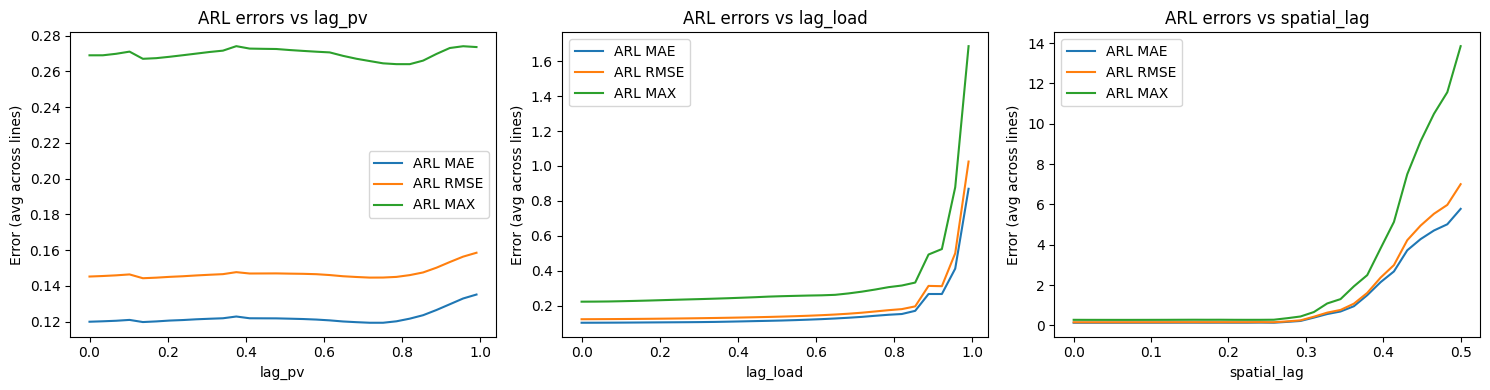

In [39]:

# ── Core function ─────────────────────────────────────────────────────────────
def run_pipeline(lag_pv, lag_load, spatial_lag, error_load=0.25, error_pv=0.5):
    np.random.seed(50)
    e1=np.random.randn(time+timeForecast)*error_pv  #Errors associated to Wind Generation
    e  = np.random.randn(nBus-1, time+timeForecast) * error_load  # ← shape (9, 36): one noise series per bus
    e2 = np.random.randn(time+timeForecast)*error_pv #Errors associated to Power Injection (Consumption) in the test period
    
    #Creation of Matrix
    II = np.zeros((nBus-1, time+timeForecast), dtype=complex)
    lines = [
        (1,2),(2,3),(3,4),(4,5),
        (2,6),(3,6),(3,7),(4,7),
        (6,8),(7,9),(8,10),(9,10)
    ]
    I_lines = np.zeros((len(lines), time+timeForecast))
    i_pv1   = np.zeros(time+timeForecast)   # PV source at Bus 5 (index 3 after slack removed)
    i_pv2   = np.zeros(time+timeForecast)   # PV source at Bus 7 (index 5 after slack removed)

    # Initializing the process of data generation
    II[:,0]=I                                      #Power Injections
    v = 1+np.dot(np.linalg.inv(Yl),I)
    v_full = np.insert(v, SlackBus-1, 1.0+0j)          # reinsert slack bus voltage
    i_pv1[0] = np.real(I[3])                            # Bus 5 is index 3 (slack Bus 1 removed)
    i_pv2[0] = np.real(I[5])                            # Bus 7 is index 5
    for k, (bi, bj) in enumerate(lines):
        I_flow = -Y[bi-1, bj-1] * (v_full[bi-1] - v_full[bj-1])
        I_lines[k, 0] = np.absolute(I_flow) * np.sign(np.real(I_flow))

    # Build bus adjacency from the line list (excluding slack Bus 1)
    # We work in the II index space (buses 2-10 → indices 0-8)
    bus_adjacency = {i: [] for i in range(nBus - 1)}
    for (bi, bj) in lines:
        i_idx = bi - 2   # shift by 2: bus 2 → index 0, etc. (slack=bus1 removed)
        j_idx = bj - 2
        if i_idx >= 0 and j_idx >= 0:   # skip connections involving slack (bus 1)
            bus_adjacency[i_idx].append(j_idx)
            bus_adjacency[j_idx].append(i_idx)

    # Process of data generation
    for t in range(time+timeForecast-1):             

        for i in range(nBus - 1):
            neighbours = bus_adjacency[i]
            neighbour_mean = np.mean(II[neighbours, t]) if neighbours else 0
            II[i, t+1] = lag_load * II[i, t] + spatial_lag * neighbour_mean + e[i, t]

        # CORRELATION LINES
        i_pv1[t+1]    = lag_pv*i_pv1[t] + e1[t]  # PV1 process with noise
        i_pv2[t+1]    = lag_pv*i_pv2[t] + e2[t]  # PV2 process with noise


        II[3,t+1] = i_pv1[t+1]+complex(0,np.imag(II[3,t+1]))   # Bus 5 injection
        II[5,t+1] = i_pv2[t+1]+complex(0,np.imag(II[5,t+1]))   # Bus 7 injection
        v      = 1+np.dot(np.linalg.inv(Yl),II[:,t+1])
        v_full = np.insert(v, SlackBus-1, 1.0+0j)
        for k, (bi, bj) in enumerate(lines):
            I_flow = -Y[bi-1, bj-1] * (v_full[bi-1] - v_full[bj-1])
            I_lines[k, t+1] = np.absolute(I_flow) * np.sign(np.real(I_flow))

    # ───────────────────────────────────────────────────────────────────────────

    nL = len(lines)
    beta_AR1L_all= np.zeros((nL, 5))        # intercept + pv1 + pv2 + lagged + load sum
    resid_AR1L   = np.zeros((nL, timeForecast-1))
    DW_AR1L = np.zeros(nL)

    load_indices = [0, 1, 2, 4, 6, 7, 8]
    load_sum = np.sum(np.real(II[load_indices, :]), axis=0)  # shape (time+timeForecast,)

    for k, (bi, bj) in enumerate(lines):
        iL = I_lines[k, :]   # current in line k, full time series

        Xt_ARL = np.ones((time-1, 5))
        Xt_ARL[:, 1] = i_pv1[1:time]
        Xt_ARL[:, 2] = i_pv2[1:time]
        Xt_ARL[:, 3] = iL[0:time-1]
        Xt_ARL[:, 4] = load_sum[1:time]
        XtT_ARL = np.transpose(Xt_ARL)
        b_ARL = np.dot(np.dot(np.linalg.inv(np.dot(XtT_ARL, Xt_ARL)), XtT_ARL), iL[1:time])
        beta_AR1L_all[k] = b_ARL

        epsilon = (iL[1:time] - (b_ARL[0] + b_ARL[1]*i_pv1[1:time] + b_ARL[2]*i_pv2[1:time]
                                + b_ARL[3]*iL[0:time-1] + b_ARL[4]*load_sum[1:time]))
        dw1 = np.sum((epsilon[1:time-1] - epsilon[0:time-2])**2)
        dw2 = np.sum((epsilon[0:time-2])**2)
        DW_AR1L[k] = np.divide(dw1, dw2)

        iL_out_ARL = (b_ARL[0] + b_ARL[1]*i_pv1[time+1:time+timeForecast]
                                + b_ARL[2]*i_pv2[time+1:time+timeForecast]
                                + b_ARL[3]*iL[time:time+timeForecast-1]
                                + b_ARL[4]*load_sum[time+1:time+timeForecast])
        resid_AR1L[k] = iL[time+1:time+timeForecast] - iL_out_ARL

    metrics = []
    for k, (bi, bj) in enumerate(lines):
        iL = I_lines[k, :]
        real_AR  = iL[time+1:time+timeForecast]   # length 11 (AR methods)

        b_ARL = beta_AR1L_all[k]

        # Forecast calculations
        fc_ARL = (b_ARL[0] + b_ARL[1]*i_pv1[time+1:time+timeForecast]
                        + b_ARL[2]*i_pv2[time+1:time+timeForecast]
                        + b_ARL[3]*iL[time:time+timeForecast-1]
                        + b_ARL[4]*load_sum[time+1:time+timeForecast])

        # Metric functions
        def mae(real, fc): return np.mean(np.abs(real - fc))
        def rmse(real, fc): return np.sqrt(np.mean((real - fc)**2))
        def max_err(real, fc): return np.max(np.abs(real - fc)) # New metric

        metrics.append([
            f"{bi}-{bj}",
            f"{mae(real_AR,  fc_ARL):.4f}", f"{rmse(real_AR,  fc_ARL):.4f}", f"{max_err(real_AR,  fc_ARL):.4f}",
        ])
    
    arr = np.array([[float(v) for v in row[1:]] for row in metrics])
    avg = np.mean(arr, axis=0)

    return avg[0], avg[1], avg[2]


# ── Sweep lag_pv ──────────────────────────────────────────────────────────────
results_pv = [run_pipeline(v, DEFAULT_LAG_LOAD, DEFAULT_SPATIAL_LAG)
              for v in sweep_lag_pv]
mae_pv, rmse_pv, max_pv = zip(*results_pv)

# ── Sweep lag_load ────────────────────────────────────────────────────────────
results_load = [run_pipeline(DEFAULT_LAG_PV, v, DEFAULT_SPATIAL_LAG)
                for v in sweep_lag_load]
mae_load, rmse_load, max_load = zip(*results_load)

# ── Sweep spatial_lag ─────────────────────────────────────────────────────────
results_spatial = [run_pipeline(DEFAULT_LAG_PV, DEFAULT_LAG_LOAD, v)
                   for v in sweep_spatial_lag]
mae_sp, rmse_sp, max_sp = zip(*results_spatial)

# ── Plotting ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, x_vals, metrics, xlabel in [
    (axes[0], sweep_lag_pv,      (mae_pv,   rmse_pv,   max_pv),   "lag_pv"),
    (axes[1], sweep_lag_load,    (mae_load, rmse_load, max_load), "lag_load"),
    (axes[2], sweep_spatial_lag, (mae_sp,   rmse_sp,   max_sp),   "spatial_lag"),
]:
    mae_, rmse_, max_ = metrics
    ax.plot(x_vals, mae_,  label="ARL MAE")
    ax.plot(x_vals, rmse_, label="ARL RMSE")
    ax.plot(x_vals, max_,  label="ARL MAX")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Error (avg across lines)")
    ax.set_title(f"ARL errors vs {xlabel}")
    ax.legend()

plt.tight_layout()
plt.savefig("lag_sweep.png", dpi=150)
plt.show()

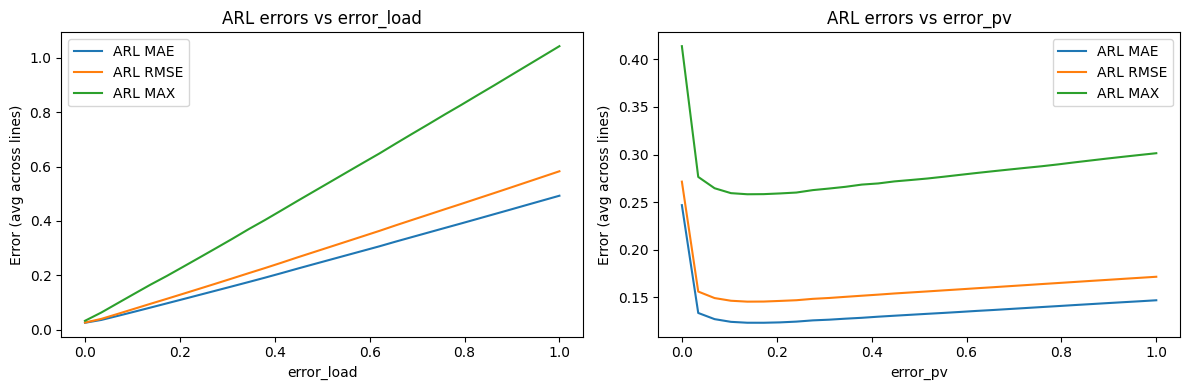

In [40]:
# ── Sweep error_load ──────────────────────────────────────────────────────────
sweep_error_load = np.linspace(0.0, 1.0, 30)
results_error_load = [run_pipeline(DEFAULT_LAG_PV, DEFAULT_LAG_LOAD, DEFAULT_SPATIAL_LAG, error_load=v)
                      for v in sweep_error_load]
mae_el, rmse_el, max_el = zip(*results_error_load)

# ── Sweep error_pv ────────────────────────────────────────────────────────────
sweep_error_pv = np.linspace(0.0, 1.0, 30)
results_error_pv = [run_pipeline(DEFAULT_LAG_PV, DEFAULT_LAG_LOAD, DEFAULT_SPATIAL_LAG, error_pv=v)
                    for v in sweep_error_pv]
mae_ep, rmse_ep, max_ep = zip(*results_error_pv)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, x_vals, metrics, xlabel in [
    (axes[0], sweep_error_load, (mae_el, rmse_el, max_el), "error_load"),
    (axes[1], sweep_error_pv,   (mae_ep, rmse_ep, max_ep), "error_pv"),
]:
    mae_, rmse_, max_ = metrics
    ax.plot(x_vals, mae_,  label="ARL MAE")
    ax.plot(x_vals, rmse_, label="ARL RMSE")
    ax.plot(x_vals, max_,  label="ARL MAX")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Error (avg across lines)")
    ax.set_title(f"ARL errors vs {xlabel}")
    ax.legend()

plt.tight_layout()
plt.savefig("error_sweep.png", dpi=150)
plt.show()